<a href="https://colab.research.google.com/github/Wilson1994/DTA-2026/blob/main/ML/ml_practice_LR%26Cl2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практика: лінійна регресія та класифікація

Це тренувальний блокнот для закріплення базового циклу ML. Завдання **нескладні** й повторюють кроки з основного тьюторіалу — тільки тепер усе робиш **сам**.

**Дві задачі на двох нових наборах даних:**
- **Задача A (регресія):** передбачити **зарплату** працівника.
- **Задача B (класифікація):** передбачити, чи **складе студент іспит** (так/ні).

**Як працювати:**
1. Запусти комірку «Підготовка даних» нижче — вона все налаштує.
2. Іди по кроках. Там, де стоїть `# TODO`, — впиши свій код.
3. Підказки є під кожним кроком.

> 💡 Усі потрібні інструменти ти вже бачив: `train_test_split`, `LinearRegression`, `DecisionTreeClassifier`, `.fit()`, `.predict()`, метрики. Тримай той блокнот поруч як шпаргалку.

---

## 🔧 Підготовка даних (просто запусти)

In [1]:
# ▶️ Просто запусти цю комірку — вона готує дані. Міняти нічого не треба.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 20)

# ---------- Дані A: ЗАРПЛАТИ (для регресії) ----------
N = 800
experience = np.random.randint(0, 31, N)                      # стаж, років
age        = (22 + experience + np.random.randint(0, 12, N)).clip(22, 64)  # вік
education  = np.random.choice([12, 15, 16, 18, 20], N,        # років освіти
                              p=[.2, .15, .35, .2, .1])
english    = np.random.randint(1, 6, N)                       # рівень англ. 1..5

salary = (8000                       # базова ставка, грн
          + experience * 900         # за кожен рік стажу
          + education  * 600         # за рік освіти
          + english    * 1500        # за рівень англійської
          + np.random.normal(0, 3000, N)   # шум: усе інше
         ).clip(8000, None)

salary_df = pd.DataFrame({
    "experience": experience, "age": age,
    "education": education, "english": english,
    "salary": salary.round(0).astype(int),
})

# ---------- Дані B: СТУДЕНТИ (для класифікації) ----------
M = 800
study     = np.random.normal(12, 5, M).clip(0, 30)            # годин навчання/тиждень
attendance= np.random.normal(78, 15, M).clip(30, 100)        # відвідуваність, %
prev_score= np.random.normal(65, 18, M).clip(0, 100)         # бал за минулий іспит
sleep     = np.random.normal(7, 1.2, M).clip(4, 10)          # годин сну

score_logit = (0.12*study + 0.04*attendance + 0.05*prev_score
               + 0.3*sleep - 9 + np.random.normal(0, 1.2, M))
passed = (score_logit > 0).astype(int)                        # 1 = склав, 0 = ні

students_df = pd.DataFrame({
    "study": study.round(1), "attendance": attendance.round(0).astype(int),
    "prev_score": prev_score.round(0).astype(int), "sleep": sleep.round(1),
    "passed": passed,
})

print("✅ Дані готові.")
print("Зарплати:", salary_df.shape, "| Студенти:", students_df.shape)
print("Частка тих, хто склав іспит:", f"{students_df['passed'].mean():.0%}")

✅ Дані готові.
Зарплати: (800, 5) | Студенти: (800, 5)
Частка тих, хто склав іспит: 69%


---
# 🟦 Задача A. Регресія: передбачаємо зарплату

Дані у таблиці `salary_df`. Ознаки: `experience` (стаж), `age` (вік), `education` (років освіти), `english` (рівень англійської 1–5). Ціль: `salary` (зарплата, грн).

Мета — навчити модель передбачати зарплату і **пояснити**, що на неї впливає.

### Крок A1. Подивись на дані
Виведи перші рядки таблиці й описову статистику. Це звичка №1 перед будь-яким навчанням.

*Підказка:* `salary_df.head()` і `salary_df.describe()`.

In [2]:
# TODO: виведи перші рядки salary_df

# TODO: виведи describe()

print(salary_df.head())

print("\nОписова статистика:")
print(salary_df.describe())

   experience  age  education  english  salary
0           6   32         15        2   23714
1          19   44         12        3   32814
2          28   54         12        5   54472
3          14   42         20        5   35964
4          10   40         18        2   29723

Описова статистика:
       experience         age   education     english        salary
count  800.000000  800.000000  800.000000  800.000000    800.000000
mean    15.418750   42.746250   15.856250    3.028750  36028.926250
std      9.328568    9.924338    2.408908    1.432826   9242.043432
min      0.000000   22.000000   12.000000    1.000000  12917.000000
25%      7.000000   35.000000   15.000000    2.000000  28550.750000
50%     16.000000   43.000000   16.000000    3.000000  36102.500000
75%     24.000000   51.000000   18.000000    4.000000  43545.500000
max     30.000000   62.000000   20.000000    5.000000  55947.000000


### Крок A2. Признач ознаки (X) і ціль (y), поділи на train / test
- `X` — усі стовпці, КРІМ `salary`.
- `y` — стовпець `salary`.
- Поділ: 20% у тест, `random_state=RANDOM_STATE`.

*Підказка:* `X = salary_df[["experience", "age", "education", "english"]]`,
`y = salary_df["salary"]`, далі `train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)`.

In [3]:
from sklearn.model_selection import train_test_split

# TODO: створи X та y
X = salary_df[["experience", "age", "education", "english"]]
y = salary_df["salary"]

# TODO: поділи на X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)


print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])

Train: 640 | Test: 160


### Крок A3. Навчи лінійну регресію
Згадай цикл: **створити → `.fit(X_train, y_train)`**.

*Підказка:* `from sklearn.linear_model import LinearRegression`, далі `model = LinearRegression()` і `model.fit(...)`.

In [4]:
from sklearn.linear_model import LinearRegression

# TODO: створи та навчи модель

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

### Крок A4. Зроби передбачення й оціни якість
- Передбач на `X_test`.
- Порахуй **MAE** та **R²**.

*Підказка:* `y_pred = model.predict(X_test)`; `mean_absolute_error(y_test, y_pred)`;
`r2_score(y_test, y_pred)`.

In [5]:
from sklearn.metrics import mean_absolute_error, r2_score

# TODO: передбач y_pred

y_pred = model.predict(X_test)

# TODO: порахуй і виведи MAE та R²

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("R²:", round(r2, 4))

MAE: 2545.33
R²: 0.8815


### Крок A5. 🔑 Інтерпретуй коефіцієнти
Дістань коефіцієнти моделі й скажи словами, яка ознака найсильніше підвищує зарплату.

*Підказка:* `model.coef_` і `model.intercept_`. Зістав назви з `X.columns`.

In [6]:
# TODO: побудуй таблицю "ознака — коефіцієнт" і відсортуй

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
}).sort_values(by="coefficient", ascending=False)

print(coef_df)
print("\nIntercept:", model.intercept_)

      feature  coefficient
3     english  1597.454634
0  experience   872.476660
2   education   609.589202
1         age    31.151182

Intercept: 6850.026177239346


✍️ **Запиши відповідь словами** (просто текстом у цій комірці, подвійний клік):
> Наиболее сильно на зарплату влияет признак english, потому что у него самый большой коэффициент в модели. Это означает, что увеличение уровня английского языка на 1 пункт приводит к наибольшему росту предсказанной зарплаты по сравнению с другими признаками.

### Крок A6. Передбач зарплату для нового працівника
Створи одного працівника й передбач його зарплату: стаж 5, вік 30, освіта 16, англійська 4.

*Підказка:* зроби `pd.DataFrame([{...}])` з тими самими назвами стовпців і передай у `model.predict(...)`.

In [7]:
# TODO: створи new_employee і передбач зарплату

new_employee = pd.DataFrame([{
    "experience": 5,
    "age": 30,
    "education": 16,
    "english": 4
}])

pred_salary = model.predict(new_employee)

print("Прогнозована зарплата:", round(pred_salary[0], 2))

Прогнозована зарплата: 28290.19


---
# 🟩 Задача B. Класифікація: чи складе студент іспит

Дані у таблиці `students_df`. Ознаки: `study` (годин навчання/тиждень), `attendance` (відвідуваність %), `prev_score` (бал за минулий іспит), `sleep` (годин сну). Ціль: `passed` (1 = склав, 0 = ні).

### Крок B1. Подивись на дані
Виведи перші рядки й перевір баланс класів: яка частка студентів склала іспит?

*Підказка:* `students_df.head()` і `students_df["passed"].mean()`.

In [8]:
# TODO: head() і частка тих, хто склав

students_df.head()

students_df["passed"].mean()

print(students_df.head())

print("\nЧастка тих, хто склав іспит:", students_df["passed"].mean())

   study  attendance  prev_score  sleep  passed
0   11.2          76          94    5.7       1
1   18.5          72          49    9.4       1
2   15.7          71          59    7.9       0
3   16.1         100          88    5.1       1
4    9.9          92          72    7.0       1

Частка тих, хто склав іспит: 0.69375


### Крок B2. X, y і поділ на train / test
- `X` — усе, крім `passed`. `y` — `passed`.
- Додай `stratify=y`, щоб пропорція класів збереглася.

*Підказка:* `train_test_split(Xs, ys, test_size=0.2, random_state=RANDOM_STATE, stratify=ys)`.

In [9]:
# TODO: Xs, ys та поділ на Xs_train, Xs_test, ys_train, ys_test

from sklearn.model_selection import train_test_split

Xs = students_df[["study", "attendance", "prev_score", "sleep"]]
ys = students_df["passed"]

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    Xs,
    ys,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=ys
)

print("Train:", Xs_train.shape[0], "| Test:", Xs_test.shape[0])
print("Баланс train:", ys_train.mean(), "| Баланс test:", ys_test.mean())

Train: 640 | Test: 160
Баланс train: 0.69375 | Баланс test: 0.69375


### Крок B3. Навчи дерево рішень
Використай `DecisionTreeClassifier` з `max_depth=3` (щоб було просте й читабельне) і `random_state=RANDOM_STATE`.

*Підказка:* `from sklearn.tree import DecisionTreeClassifier`.

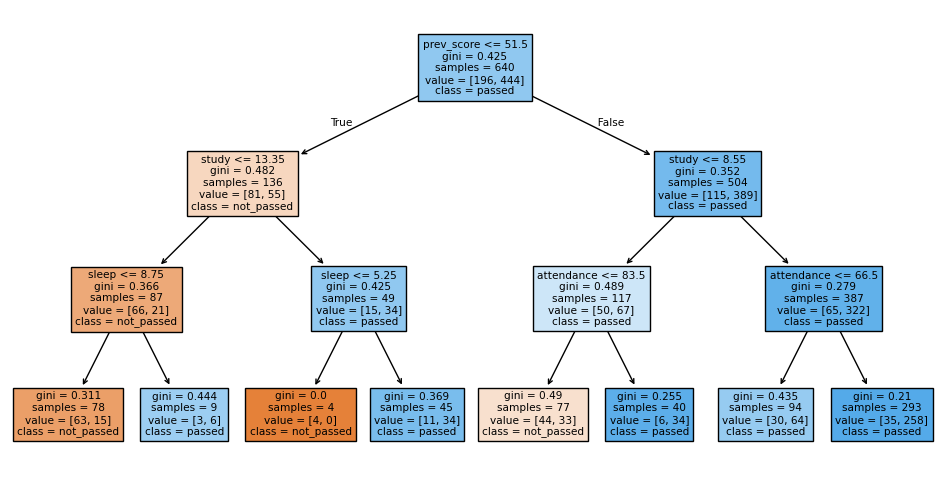

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# TODO: створи та навчи дерево

tree_model = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)

tree_model.fit(Xs_train, ys_train)


plt.figure(figsize=(12,6))
plot_tree(
    tree_model,
    feature_names=Xs.columns,
    class_names=["not_passed", "passed"],
    filled=True
)
plt.show()

### Крок B4. Передбач і оціни
- Передбач на `Xs_test`.
- Порахуй **accuracy** і побудуй **матрицю плутанини**.

*Підказка:* `accuracy_score(ys_test, ys_pred)` та `confusion_matrix(ys_test, ys_pred)`.

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix

# TODO: передбач ys_pred, порахуй accuracy та матрицю плутанини

ys_pred = tree_model.predict(Xs_test)

acc = accuracy_score(ys_test, ys_pred)

cm = confusion_matrix(ys_test, ys_pred)

print("Accuracy:", round(acc, 4))
print("Confusion matrix:\n", cm)

Accuracy: 0.7562
Confusion matrix:
 [[25 24]
 [15 96]]


### Крок B5. Що найбільше впливає на результат?
Виведи важливість ознак дерева й назви найважливішу.

*Підказка:* `tree.feature_importances_`, зістав із `Xs.columns`.

In [12]:
# TODO: таблиця "ознака — важливість", відсортована за спаданням

importance_df = pd.DataFrame({
    "feature": Xs.columns,
    "importance": tree_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance_df)



      feature  importance
2  prev_score    0.377026
0       study    0.325006
1  attendance    0.195933
3       sleep    0.102035


✍️ **Відповідь словами:**
> Наибольшее влияние на сдачу экзамена оказывает признак prev_score, потому что он имеет наибольшую важность в модели дерева решений.

### Крок B6. Передбач для нового студента
Студент: навчання 15 год, відвідуваність 85%, минулий бал 70, сон 7.5.
Виведи і рішення (`predict`), і **ймовірність** скласти (`predict_proba`).

*Підказка:* `predict_proba(...)[0, 1]` — це ймовірність класу «склав».

In [13]:
# TODO: створи new_student, виведи рішення та ймовірність

new_student = pd.DataFrame([{
    "study": 15,
    "attendance": 85,
    "prev_score": 70,
    "sleep": 7.5
}])

pred_class = tree_model.predict(new_student)[0]

pred_proba = tree_model.predict_proba(new_student)[0, 1]

print("Рішення (0 = не склав, 1 = склав):", pred_class)
print("Ймовірність скласти іспит:", round(pred_proba, 4))

Рішення (0 = не склав, 1 = склав): 1
Ймовірність скласти іспит: 0.8805


---
# ⭐ Бонус (необов'язково, але корисно)

1. **Перевір на перенавчання.** Для дерева зі Задачі B порахуй accuracy окремо на `Xs_train` і на `Xs_test`. Великий розрив = зубріння. Потім спробуй `max_depth=10` — розрив зросте?
2. **Сильніша модель.** Навчи `RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)` на тих самих даних і порівняй accuracy з деревом.
3. **Прибери ознаку.** У Задачі A прибери `experience` з `X`, перенавчи й подивись, як впаде R². Який висновок про важливість стажу?

In [15]:
# Місце для бонусних експериментів
from sklearn.metrics import accuracy_score

train_pred = tree_model.predict(Xs_train)
test_pred = tree_model.predict(Xs_test)

train_acc = accuracy_score(ys_train, train_pred)
test_acc = accuracy_score(ys_test, test_pred)

print("Train accuracy:", round(train_acc, 4))
print("Test accuracy:", round(test_acc, 4))
print("Розрив:", round(train_acc - test_acc, 4))

Train accuracy: 0.7922
Test accuracy: 0.7562
Розрив: 0.0359


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_model.fit(Xs_train, ys_train)

rf_pred = rf_model.predict(Xs_test)
rf_acc = accuracy_score(ys_test, rf_pred)

print("RandomForest accuracy:", round(rf_acc, 4))

RandomForest accuracy: 0.7688


---
# 🧠 Питання на розуміння (без коду)

Дай собі відповідь словами (правильні — у блокноті з розв'язками):
1. Чому ми оцінюємо модель на `X_test`, а не на `X_train`?
2. Задача «передбачити кількість проданих квитків» — це регресія чи класифікація? А «спам / не спам»?
3. Що означає R² = 0.85 простими словами?
4. Чому accuracy може бути оманливою, якщо лише 5% студентів провалюють іспит?
5. Коефіцієнт `english = +1500`. Як прочитати це вголос для керівника?

> 🎯 Якщо впорався із задачами A і B без підглядання — ти впевнено володієш базовим циклом ML. Вітаю!

1) Мы оцениваем модель на X_test, а не на X_train, чтобы проверить, как она работает на новых, ранее не виденных данных. Если оценивать на X_train, модель уже видела эти примеры во время обучения и может просто их запомнить.
2) Предсказать количество проданных билетов это регрессия. Потому что результат это число, то есть непрерывная величина.
Спам / не спам это классификация. Потому что результат — это категория класс.
3) R² = 0.85 означает что модель объясняет примерно 85% вариации данных. Модель довольно хорошо предсказывает результат. 85% изменений в целевой переменной можно объяснить входными признаками.
4) Accuracy может быть обманчивой при несбалансированных классах. В нашем случае только 5% студентов проваливают экзамен, а 95% - сдают. Если модель просто всегда будет говорить все сдали, то она правильно угадает 95% случаев, accuracy будет 95%.
5) Каждый дополнительный уровень английского языка в модели в среднем увеличивает прогнозируемую зарплату примерно на 1500 при прочих равных условиях.
